In [ ]:
%matplotlib inline
%config Inlin eBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# import arviz as az

import h5py
# import glob

import sxs

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [3]:
t0 = 1126259462.423
ra = 1.952318922
dec = -1.26967171703
psi = 0.824043851821

In [4]:
### Fit object whose data was not line subtracted
fit = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon/engine/1126259462.423000/config.ini')

### Fit object whose data WAS line subtracted
fit_sub = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon/engine/1126259462.423000/config.ini')

### empty Fit object for comparison
temp_fit = rd.Fit()

In [5]:
### This is data WITHOUT line subtraction
wf = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon_H1.hdf5', key='H1')

### This is data WITH line subtraction
wf_sub = pd.read_hdf('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/linesub/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon_H1.hdf5', key='H1')

In [6]:
ipad = np.argmin(np.abs(wf.values)) - 1
padding_time = wf.index.values[ipad]

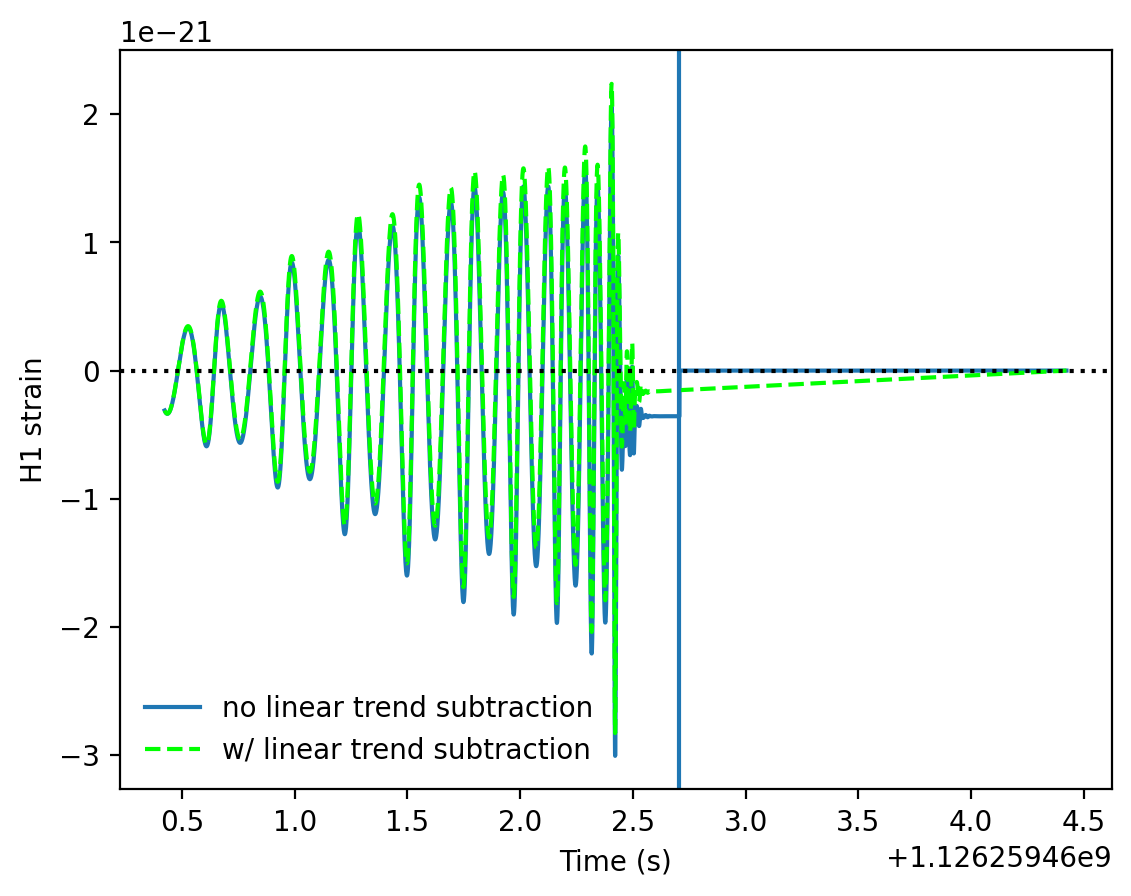

In [7]:
plt.plot(wf, label='no linear trend subtraction')
plt.plot(wf_sub, ls='--', color='lime', label='w/ linear trend subtraction')
plt.axhline(0, c='k', ls=':')

ipad = np.argmin(np.abs(wf.values)) - 1
padding_time = wf.index.values[ipad]
plt.axvline(padding_time)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

plt.legend(frameon=False)

### Upon injection, it seems the waveforms get padded with zeroes by default to fill out the time array

In [8]:
### Let's instead pad the waveform with roughly the final value of h from the sim

# ipad = np.argmin(np.abs(wf.index.values - padding_time))
wf.iloc[ipad:] = wf.iloc[ipad]

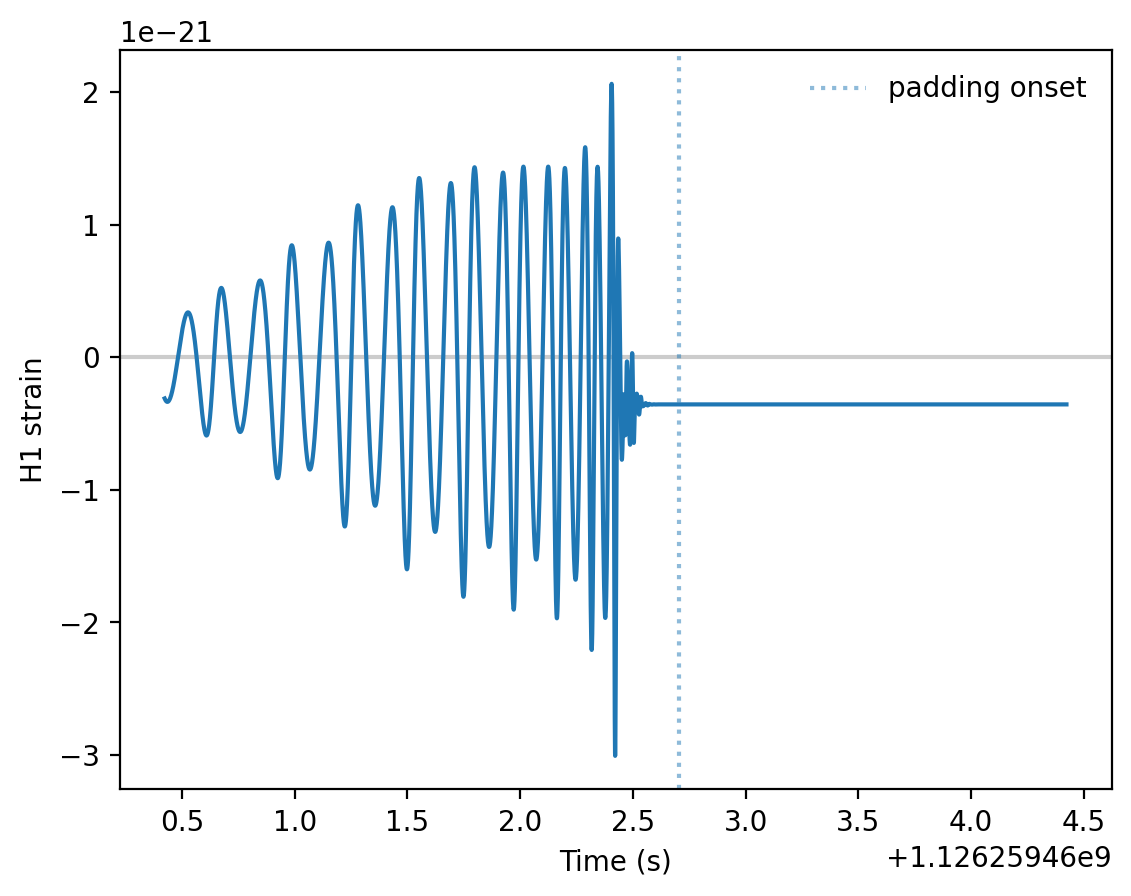

In [9]:
plt.plot(wf)
plt.axhline(0, c='k', ls='-', zorder=-10, alpha=0.2)
plt.axvline(padding_time, alpha=0.5, ls=':', label='padding onset')

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

plt.legend(frameon=False)

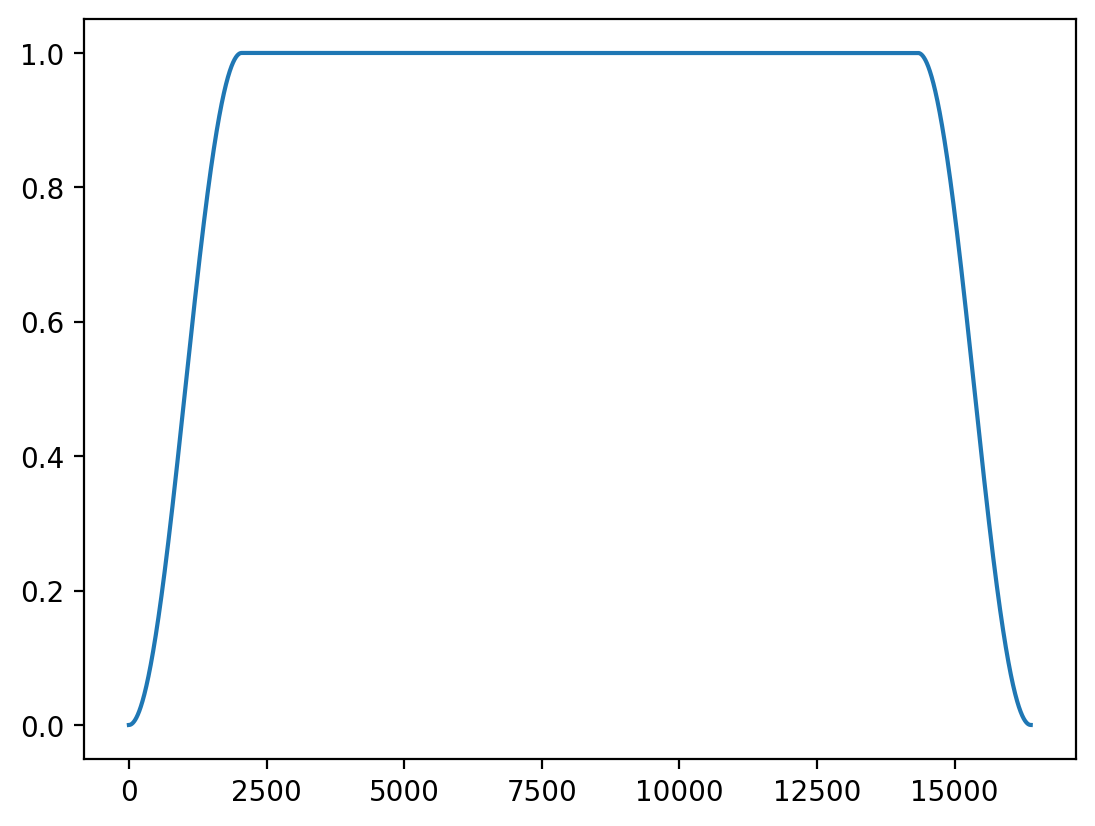

In [10]:
import scipy.signal as ss

window = ss.windows.tukey(len(wf), 0.25)

plt.plot(window)

In [11]:
dt = 1/4096
pad_lo = np.arange(wf.index.values[0] - dt*0.25*len(wf), wf.index.values[0], dt)
pad_hi = np.arange(wf.index.values[-1]+dt, dt*(1 + 0.25*len(wf)) + wf.index.values[-1], dt)

In [12]:
pad_lo = pd.Series(np.zeros(len(pad_lo)), index=pad_lo)
pad_hi = pd.Series(np.zeros(len(pad_hi)), index=pad_hi)

In [13]:
pad_lo, pad_hi

(1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
                ... 
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 Length: 4096, dtype: float64,
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
                ... 
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 1.126259e+09    0.0
 Length: 4096, dtype: float64)

In [14]:
# pp_wf = pd.concat([pad_lo, wf*window, pad_hi])
pp_wf = pd.concat([wf*window])
pp_wf

1.126259e+09   -0.000000e+00
1.126259e+09   -1.836823e-28
1.126259e+09   -7.370836e-28
1.126259e+09   -1.663630e-27
1.126259e+09   -2.966607e-27
                    ...     
1.126259e+09   -3.351912e-27
1.126259e+09   -1.885453e-27
1.126259e+09   -8.379800e-28
1.126259e+09   -2.094951e-28
1.126259e+09   -0.000000e+00
Name: H1, Length: 16384, dtype: float64

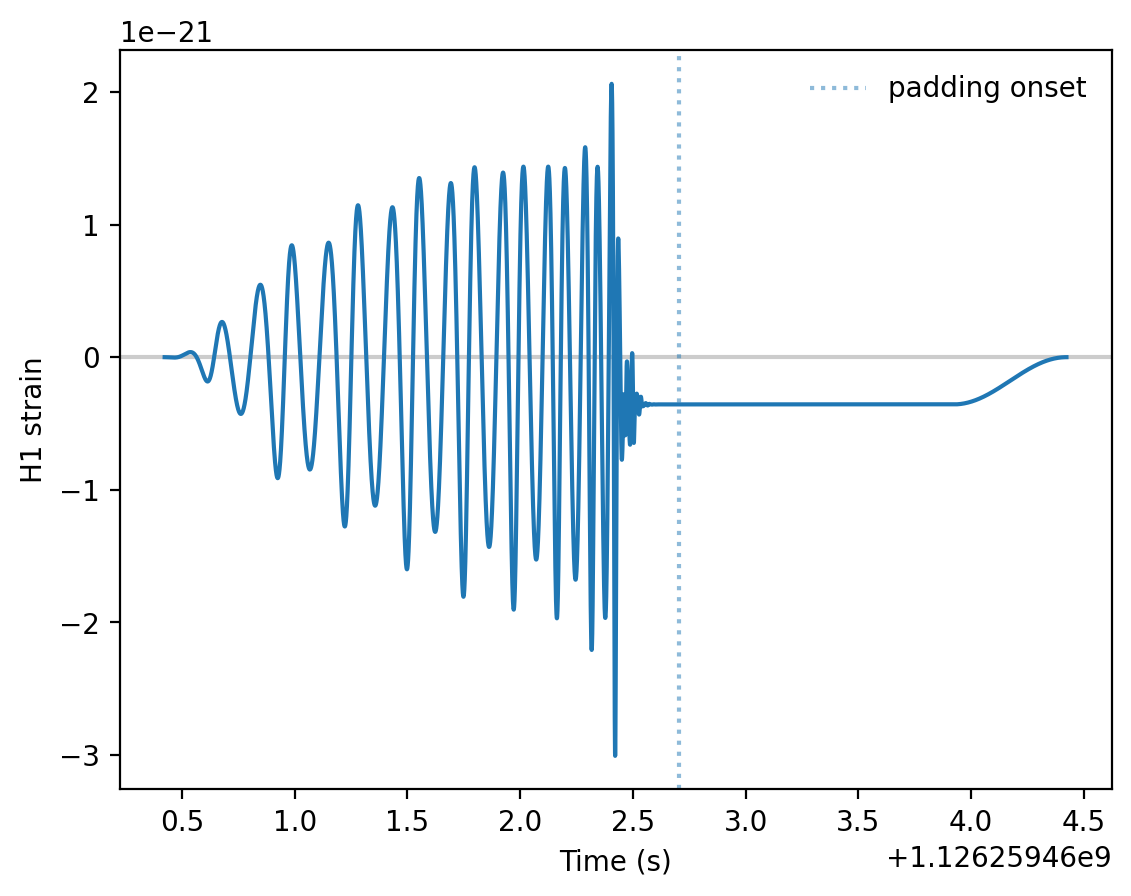

In [15]:
plt.plot(pp_wf.index.values, pp_wf.values)
plt.axhline(0, c='k', ls='-', zorder=-10, alpha=0.2)
plt.axvline(padding_time, alpha=0.5, ls=':', label='padding onset')

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')

plt.legend(frameon=False)

In [16]:
# ts = sxs.TimeSeries(wf.values, time=wf.index.values)
# ts_sub = ts.line_subtraction() ### apply line subtraction

In [17]:
# plt.plot(ts_sub)
# plt.axhline(0, c='k', ls=':')

# plt.xlabel('Time (s)')
# plt.ylabel('H1 strain')

In [18]:
# temp_fit.add_data(rd.Data(ts_sub.ndarray, index=ts_sub.time, ifo='H1'))

In [19]:
temp_fit.add_data(rd.Data(pp_wf.values, index=pp_wf.index.values, ifo='H1'))

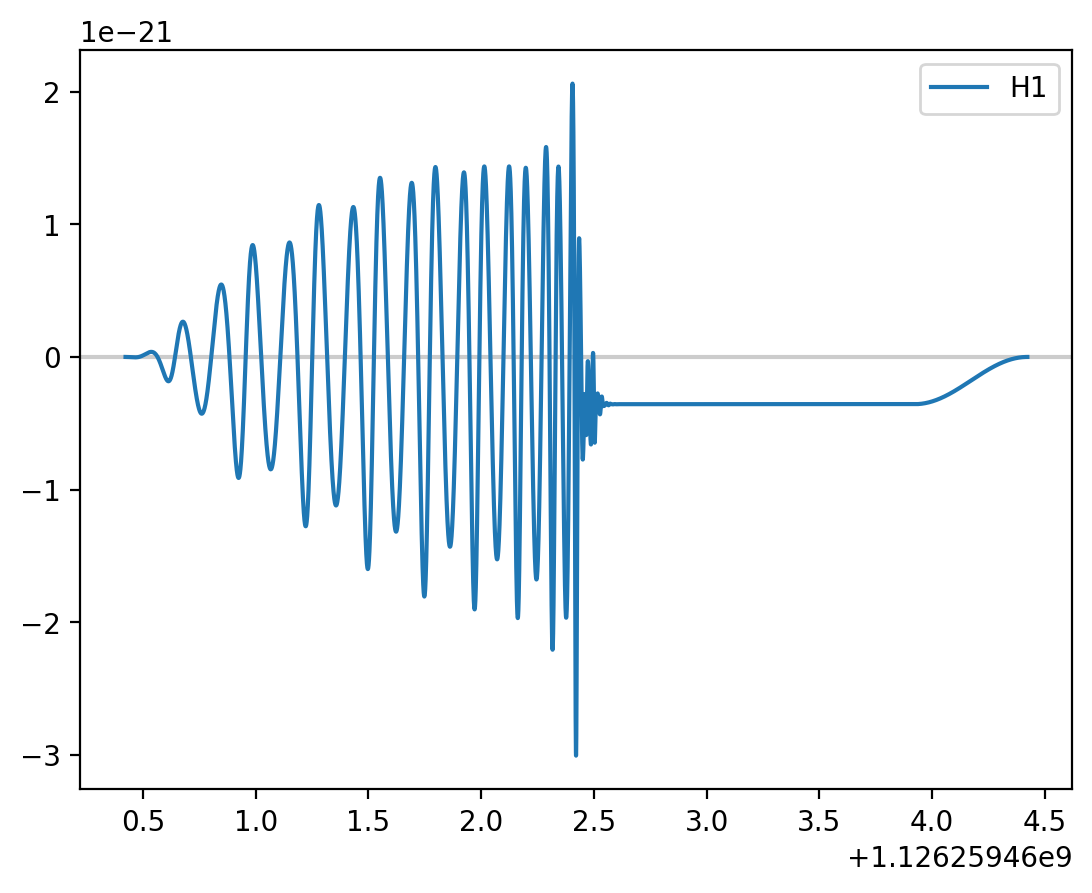

In [20]:
for i, d in temp_fit.data.items():
    plt.plot(d, label=i)

plt.axhline(0, c='k', ls='-', zorder=-10, alpha=0.2)
plt.legend()

In [21]:
temp_fit.set_target(t0=t0, 
                ra=ra, 
                dec=dec, 
                psi=psi, 
                duration=0.5)

In [22]:
temp_fit.condition_data(f_min=10, ds=1, trim=0)

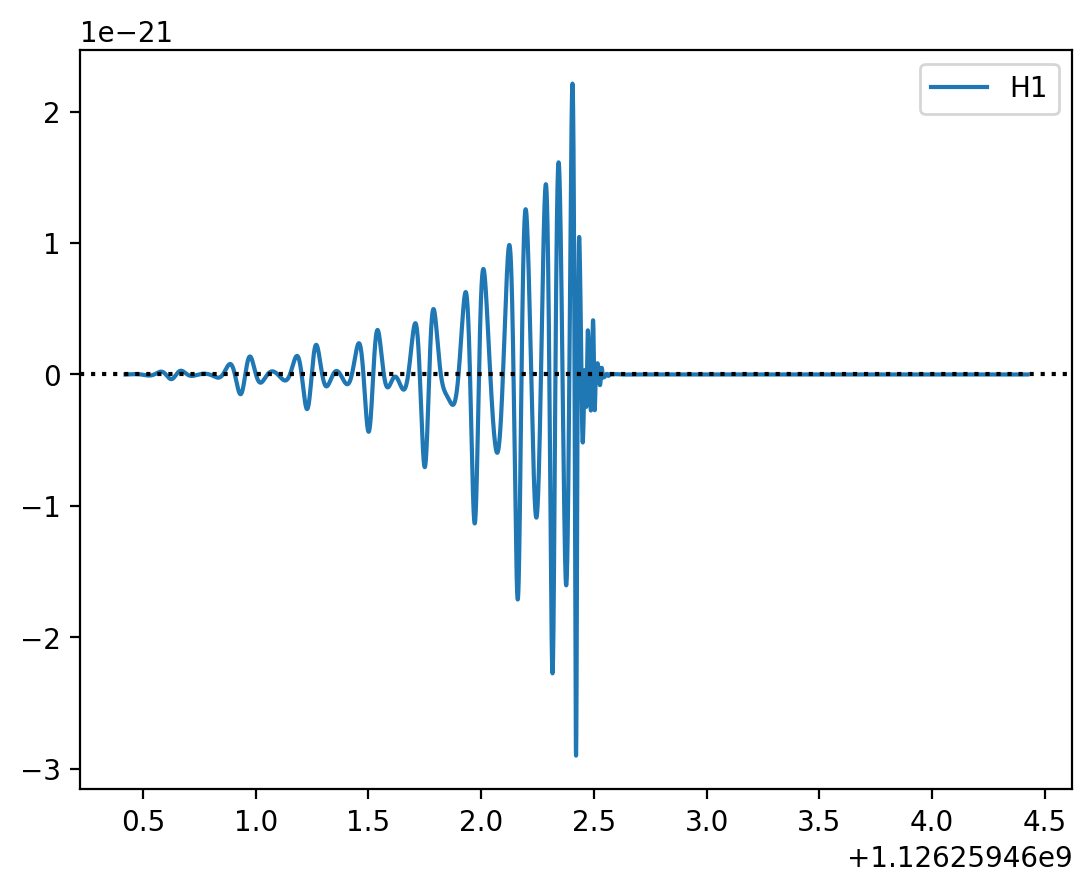

In [23]:
for i, d in temp_fit.data.items():
    plt.plot(d, label=i)
plt.axhline(0, c='k', ls=':')

plt.legend()

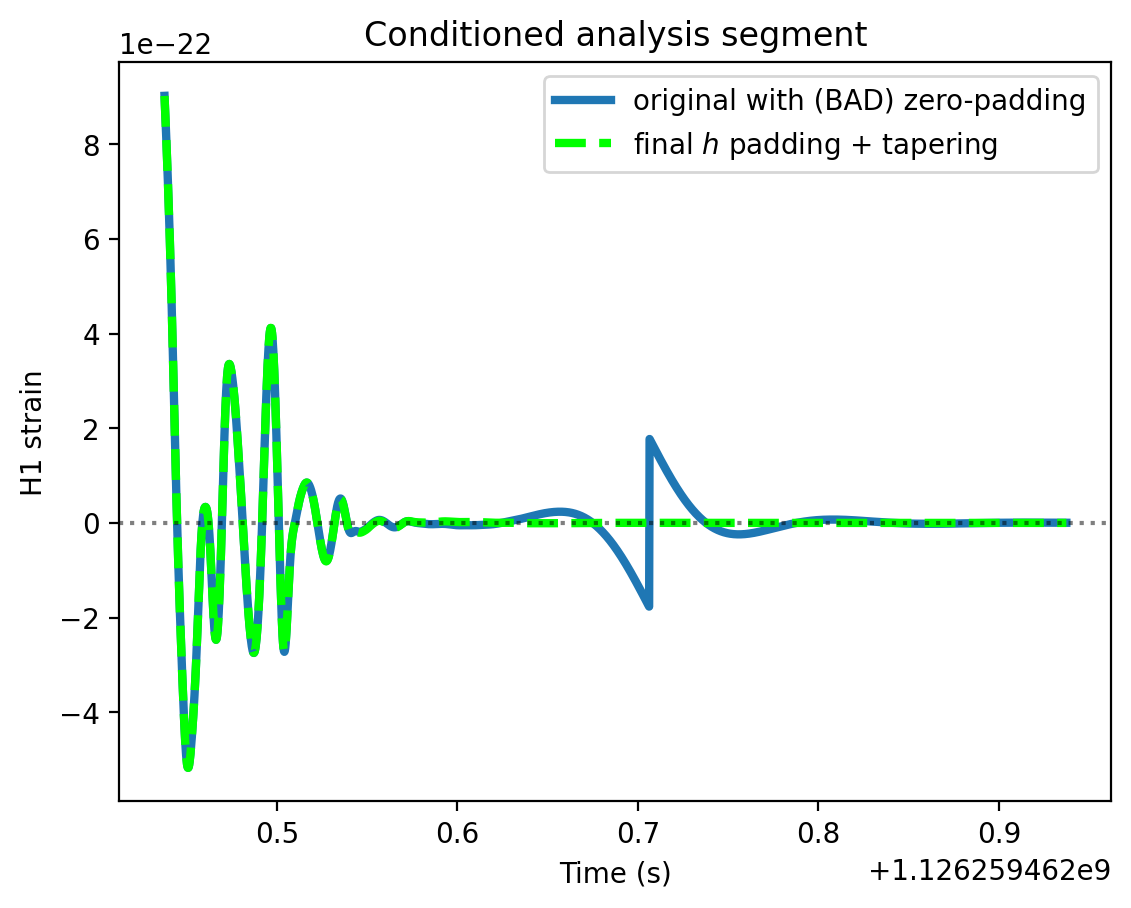

In [24]:
plt.plot(fit.analysis_data['H1'], lw=3, label='original with (BAD) zero-padding')
plt.plot(temp_fit.analysis_data['H1'], ls='--', color='lime', lw=3, label='final $h$ padding + tapering')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned analysis segment')

plt.legend()

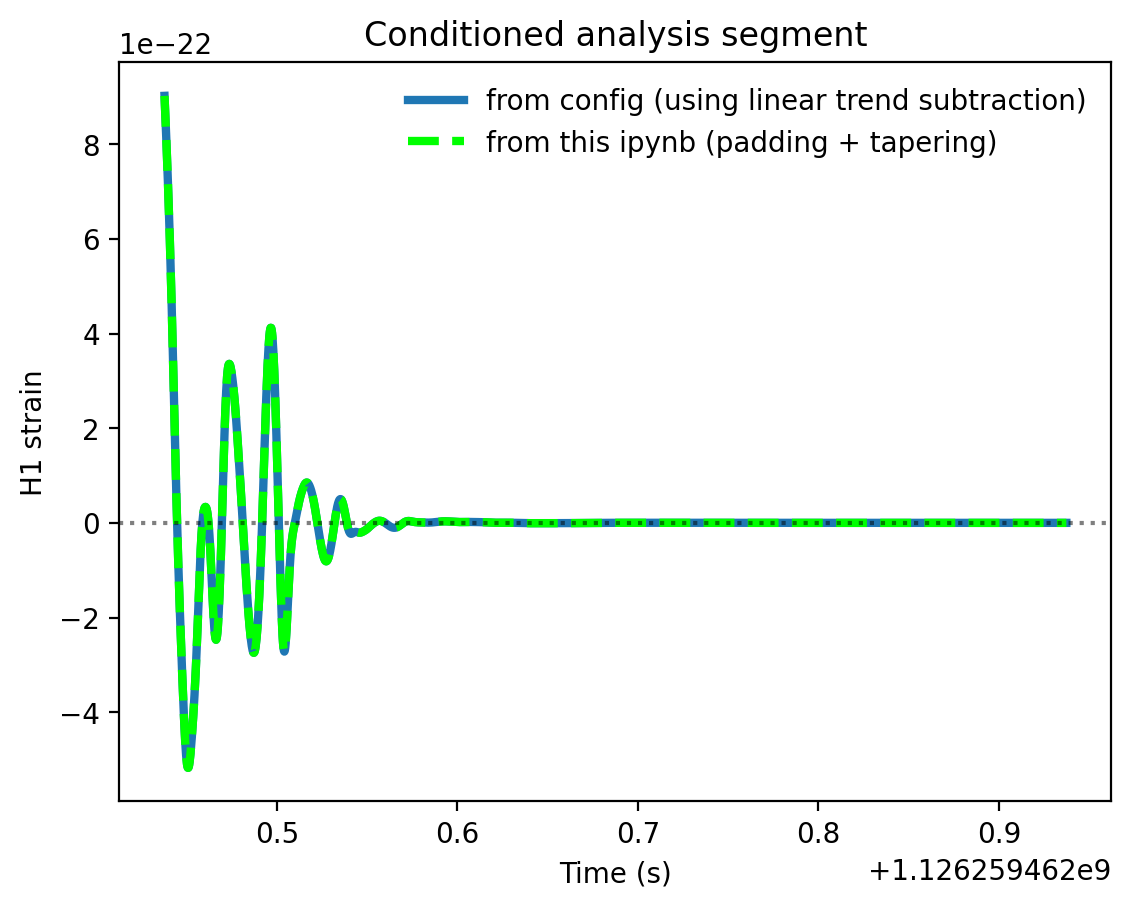

In [25]:
plt.plot(fit_sub.analysis_data['H1'], lw=3, label='from config (using linear trend subtraction)')
plt.plot(temp_fit.analysis_data['H1'], ls='--', color='lime', lw=3, label='from this ipynb (padding + tapering)')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned analysis segment')

plt.legend(frameon=False)

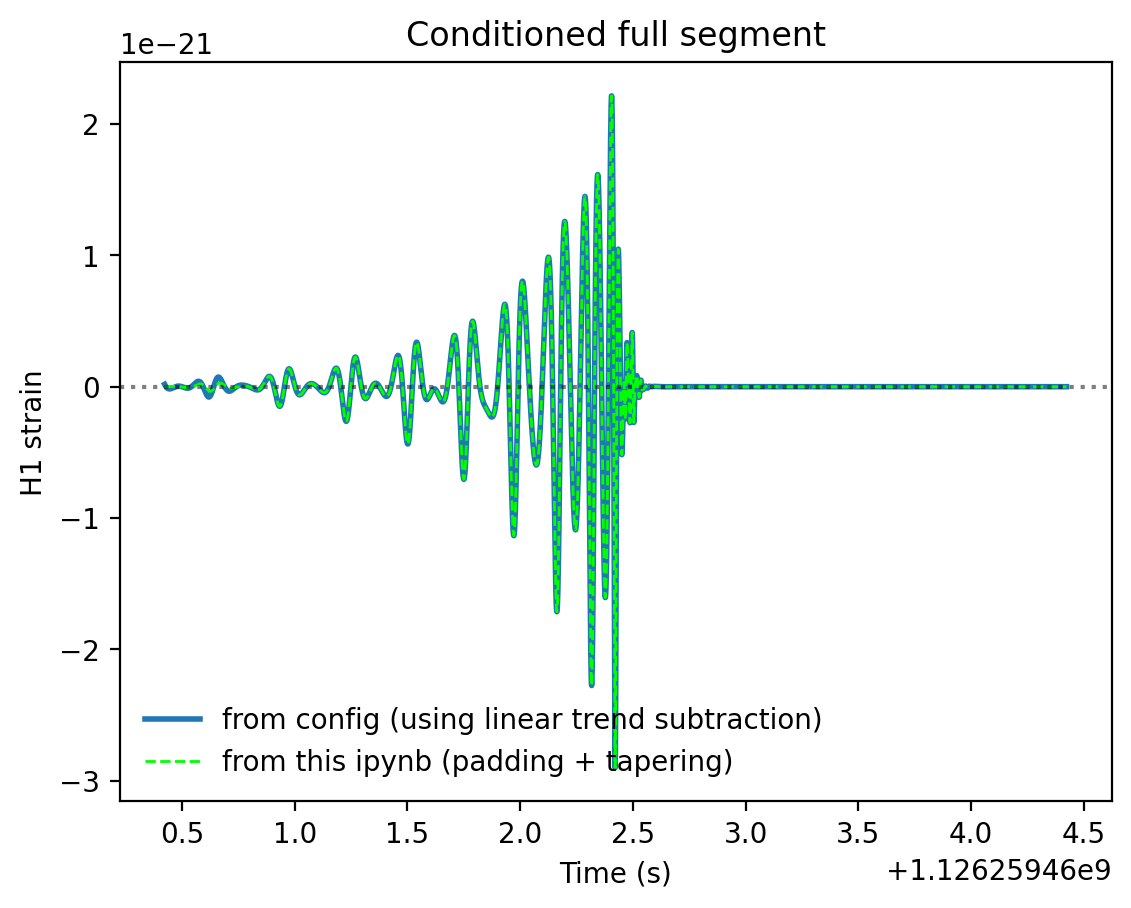

In [26]:
plt.plot(fit_sub.data['H1'], lw=2, label='from config (using linear trend subtraction)')
plt.plot(temp_fit.data['H1'], ls='--', color='lime', lw=1, label='from this ipynb (padding + tapering)')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned full segment')

plt.legend(frameon=False)

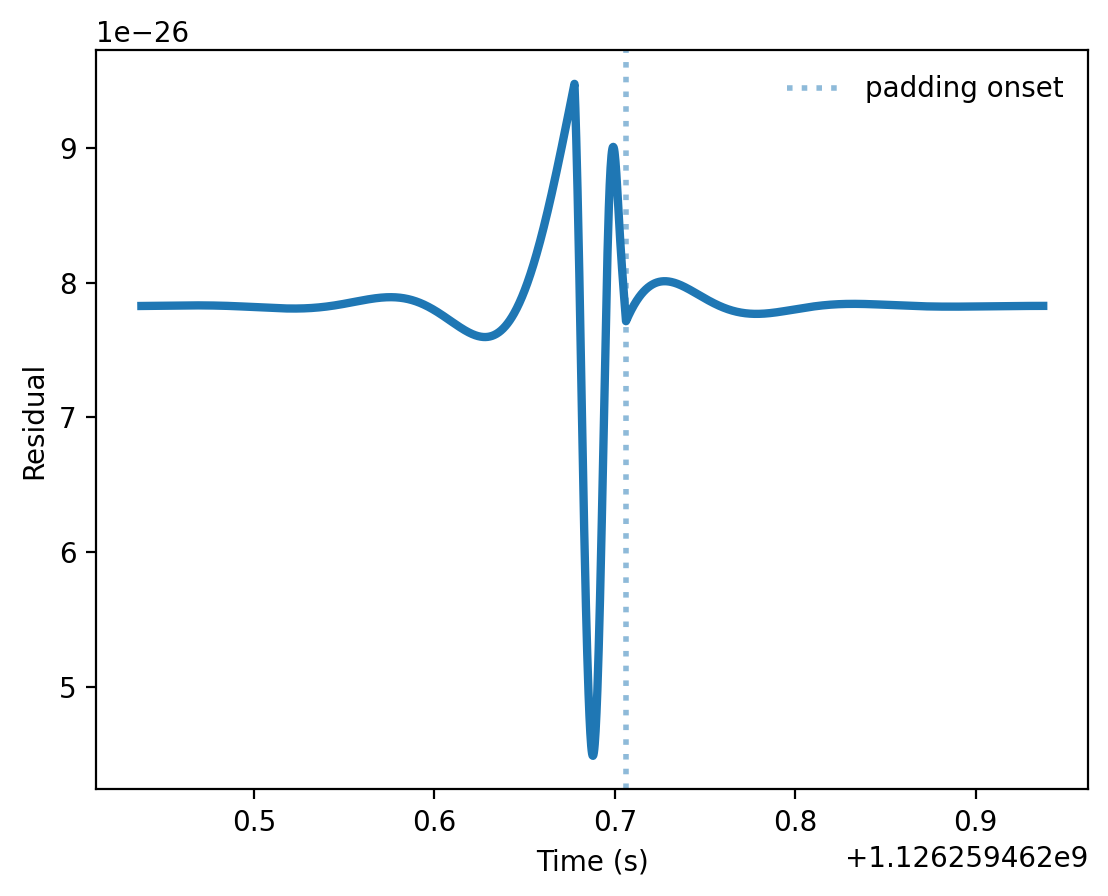

In [27]:
plt.plot(fit_sub.analysis_data['H1'] - temp_fit.analysis_data['H1'], lw=3)
# plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.axvline(padding_time, lw=2, alpha=0.5, ls=':', label='padding onset')

# plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Residual')
# plt.title('Conditioned line-subtracted analysis segment')

plt.legend(frameon=False)

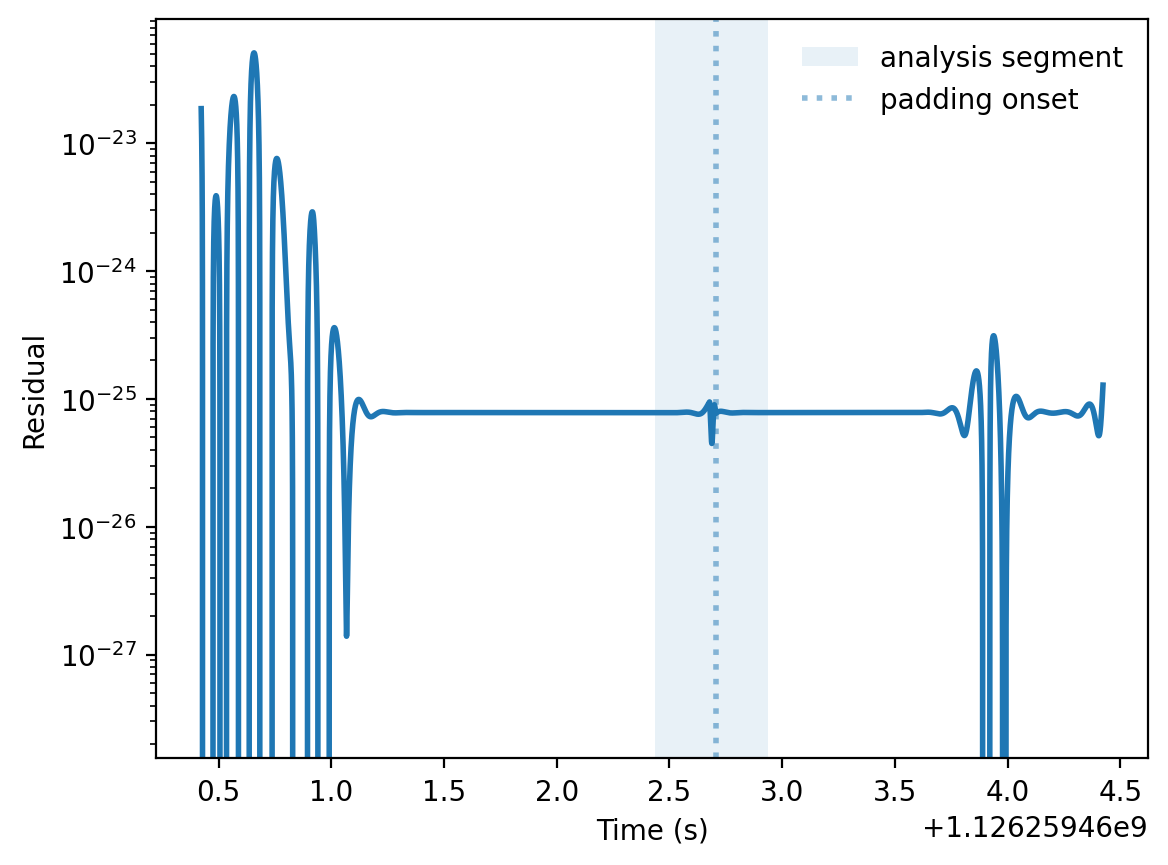

In [28]:
plt.plot(fit_sub.data['H1'] - temp_fit.data['H1'], lw=2)
# plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.axvspan(temp_fit.analysis_times['H1'][0], temp_fit.analysis_times['H1'][-1], alpha=0.1, lw=0, label='analysis segment')
plt.axvline(padding_time, lw=2, alpha=0.5, ls=':', label='padding onset')

plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Residual')
# plt.title('Conditioned line-subtracted analysis segment')

plt.legend(frameon=False)

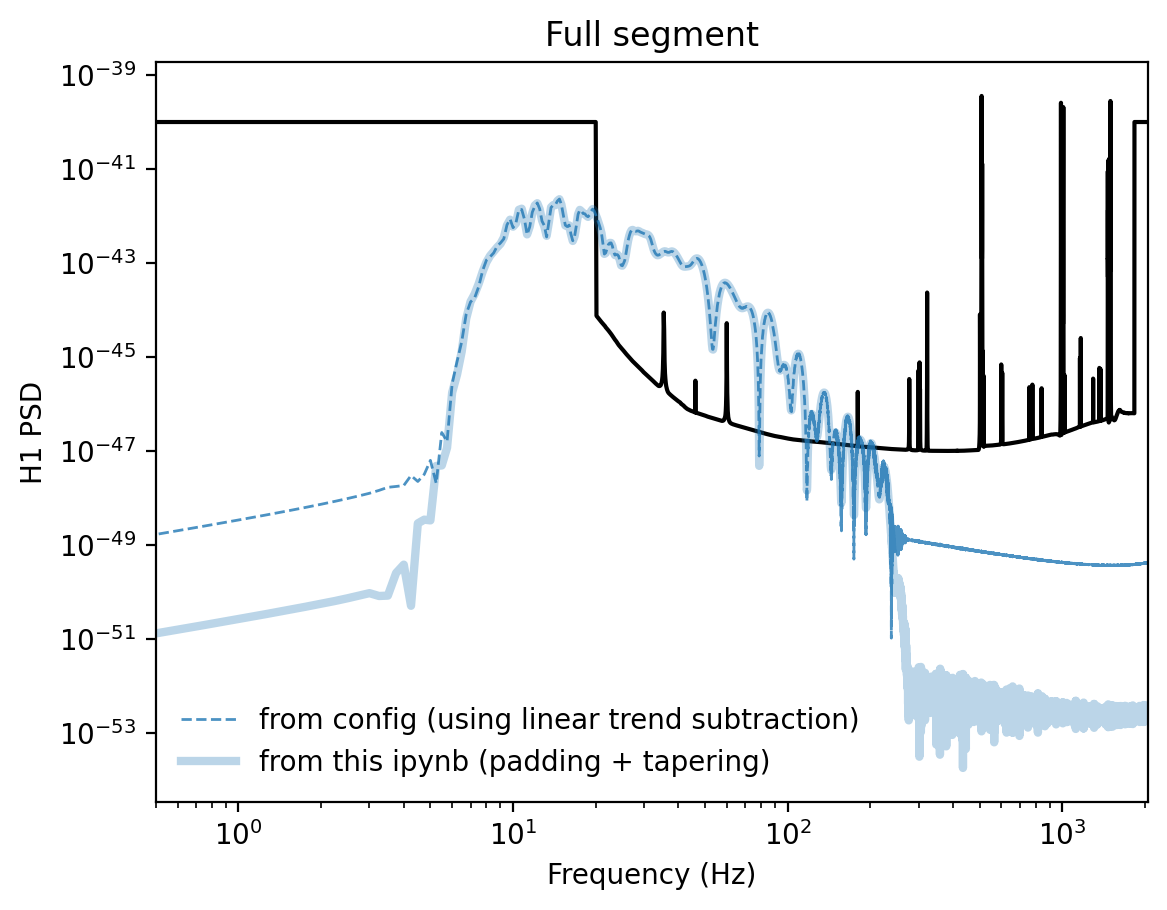

In [29]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')

dt = 1/4096
h_freq = np.fft.rfft(fit_sub.data['H1'].values)*dt
fs = np.fft.rfftfreq(len(fit_sub.data['H1'].index.values), d=dt)
l, = ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=1, ls='--', alpha=0.8, label='from config (using linear trend subtraction)')

h_freq_c = np.fft.rfft(temp_fit.data['H1'].values)*dt
fs_c = np.fft.rfftfreq(len(temp_fit.data['H1'].index.values), d=dt)
ax.loglog(fs_c, 4*fs_c*np.abs(h_freq_c)**2, lw=3, ls='-', alpha=0.3, color=l.get_color(), label='from this ipynb (padding + tapering)')

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("H1 PSD")
ax.set_title('Full segment')
ax.set_xlim(0.5, 2048)
ax.legend(frameon=False)

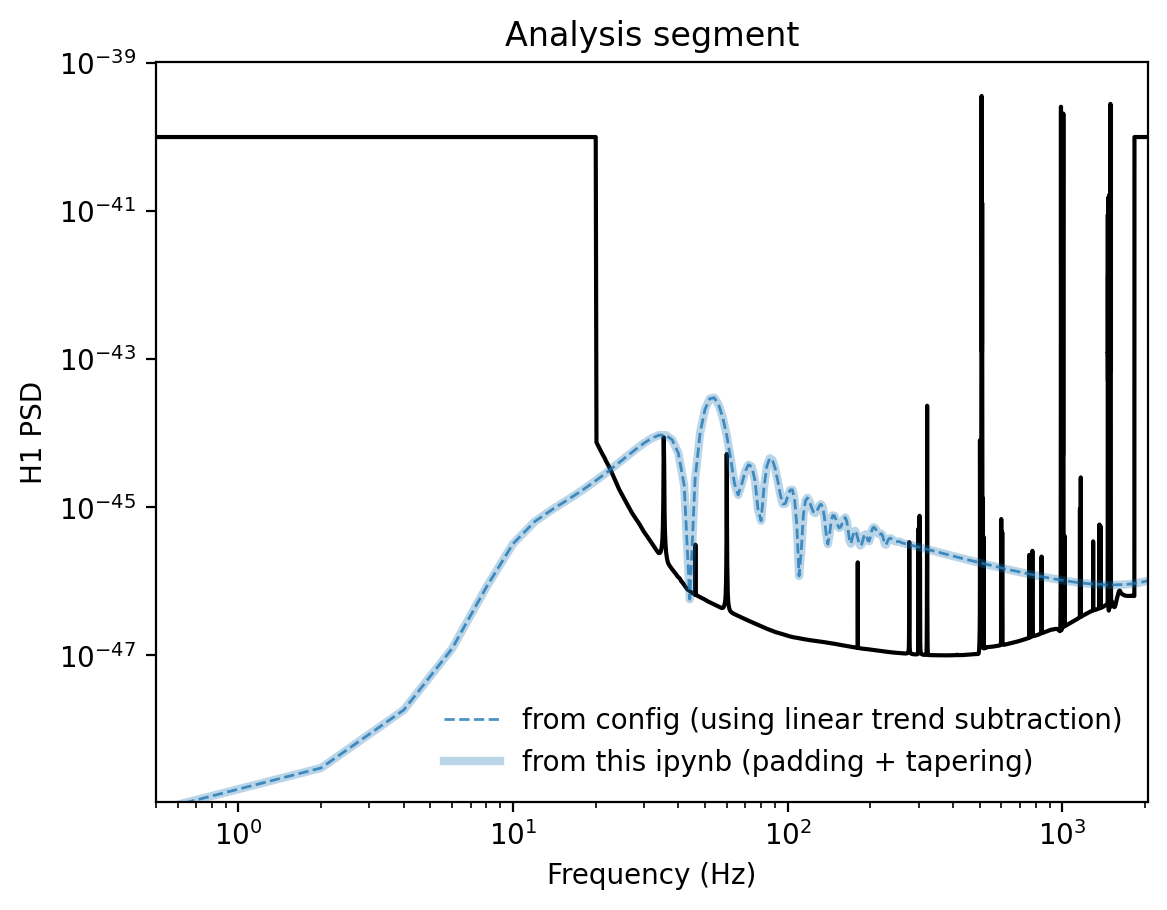

In [30]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')

dt = 1/4096
h_freq = np.fft.rfft(fit_sub.analysis_data['H1'].values)*dt
fs = np.fft.rfftfreq(len(fit_sub.analysis_data['H1'].index.values), d=dt)
l, = ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=1, ls='--', alpha=0.8, label='from config (using linear trend subtraction)')

h_freq_c = np.fft.rfft(temp_fit.analysis_data['H1'].values)*dt
fs_c = np.fft.rfftfreq(len(temp_fit.analysis_data['H1'].index.values), d=dt)
ax.loglog(fs_c, 4*fs_c*np.abs(h_freq_c)**2, lw=3, ls='-', alpha=0.3, color=l.get_color(), label='from this ipynb (padding + tapering)')

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("H1 PSD")
ax.set_title('Analysis segment')
ax.set_xlim(0.5, 2048)
ax.legend(frameon=False)

In [31]:
fit_pt = rd.Fit()
fit_pt.set_target(t0=t0, ra=ra, dec=dec, psi=psi, duration=0.5)

fit_ls = fit_pt.copy()

In [32]:
fit_pt.add_data(rd.Data(pp_wf.values, index=pp_wf.index.values, ifo='H1'))
fit_ls.add_data(rd.Data(wf_sub.values, index=wf_sub.index.values, ifo='H1'))

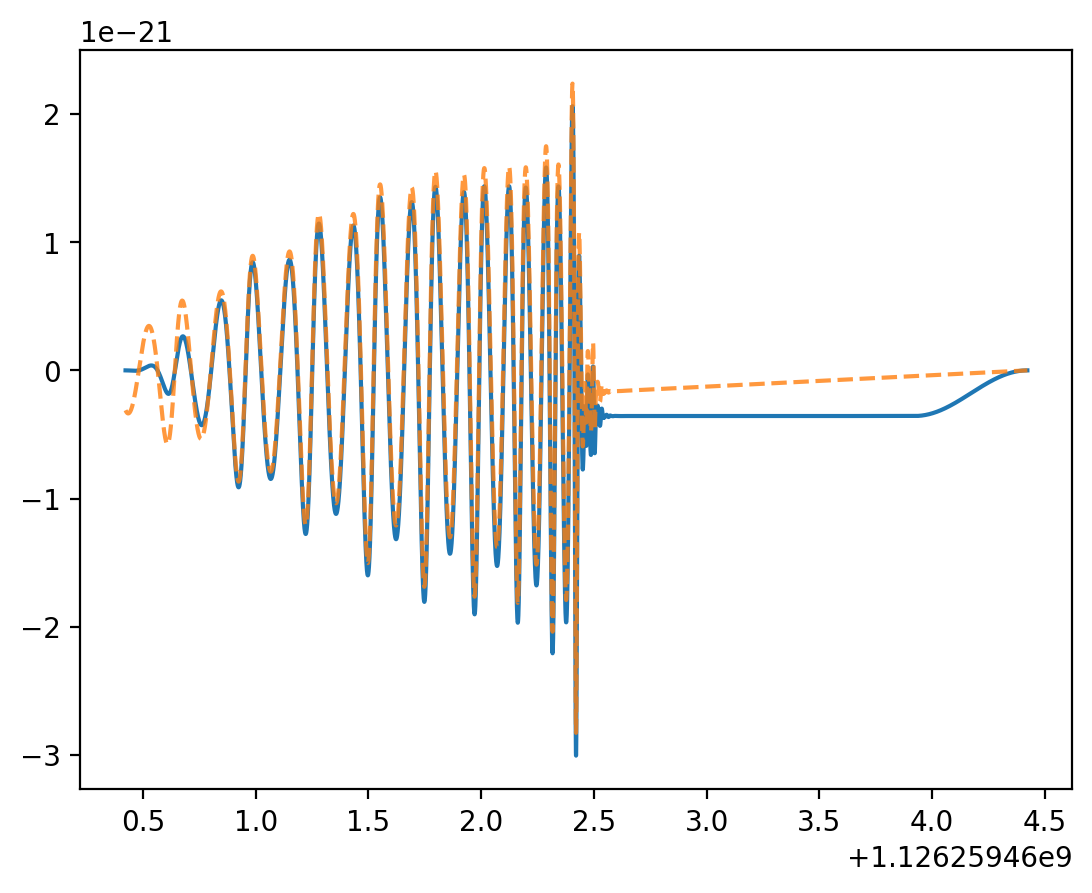

In [33]:
for i in fit_pt.ifos:
    l, = plt.plot(fit_pt.data[i], zorder=-10)
    plt.plot(fit_ls.data[i], ls='--', alpha=0.8)

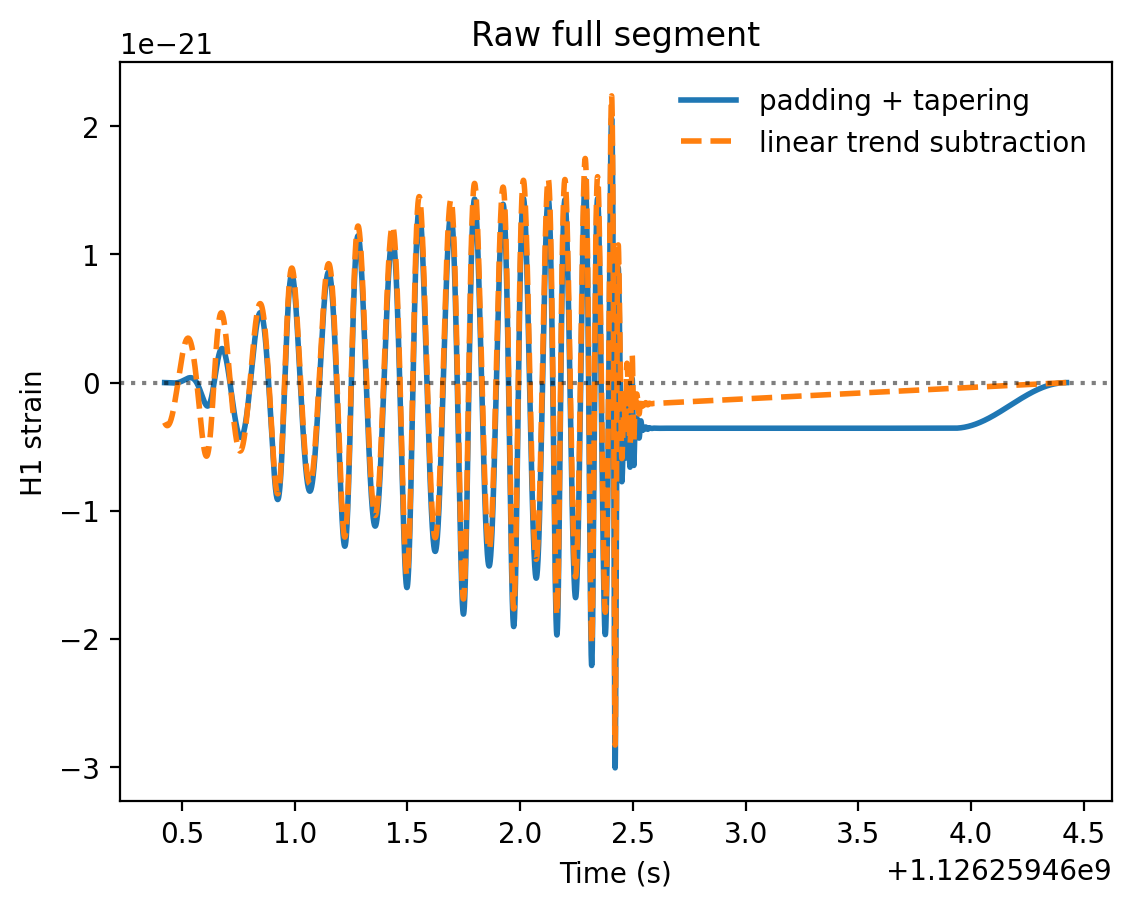

In [34]:
plt.plot(fit_pt.data['H1'], lw=2, label='padding + tapering')
plt.plot(fit_ls.data['H1'], ls='--', lw=2, label='linear trend subtraction')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Raw full segment')

plt.legend(frameon=False)

In [35]:
fit_pt.condition_data(f_min=10, ds=1, trim=0)
fit_ls.condition_data(f_min=10, ds=1, trim=0)

In [48]:
fit_pt.load_acfs(path={'H1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_H1_psd_patched4kHz_1e-40.hdf5', 'L1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_L1_psd_patched4kHz_1e-40.hdf5'}, from_psd=True)

fit_ls.load_acfs(path={'H1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_H1_psd_patched4kHz_1e-40.hdf5', 'L1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_L1_psd_patched4kHz_1e-40.hdf5'}, from_psd=True)

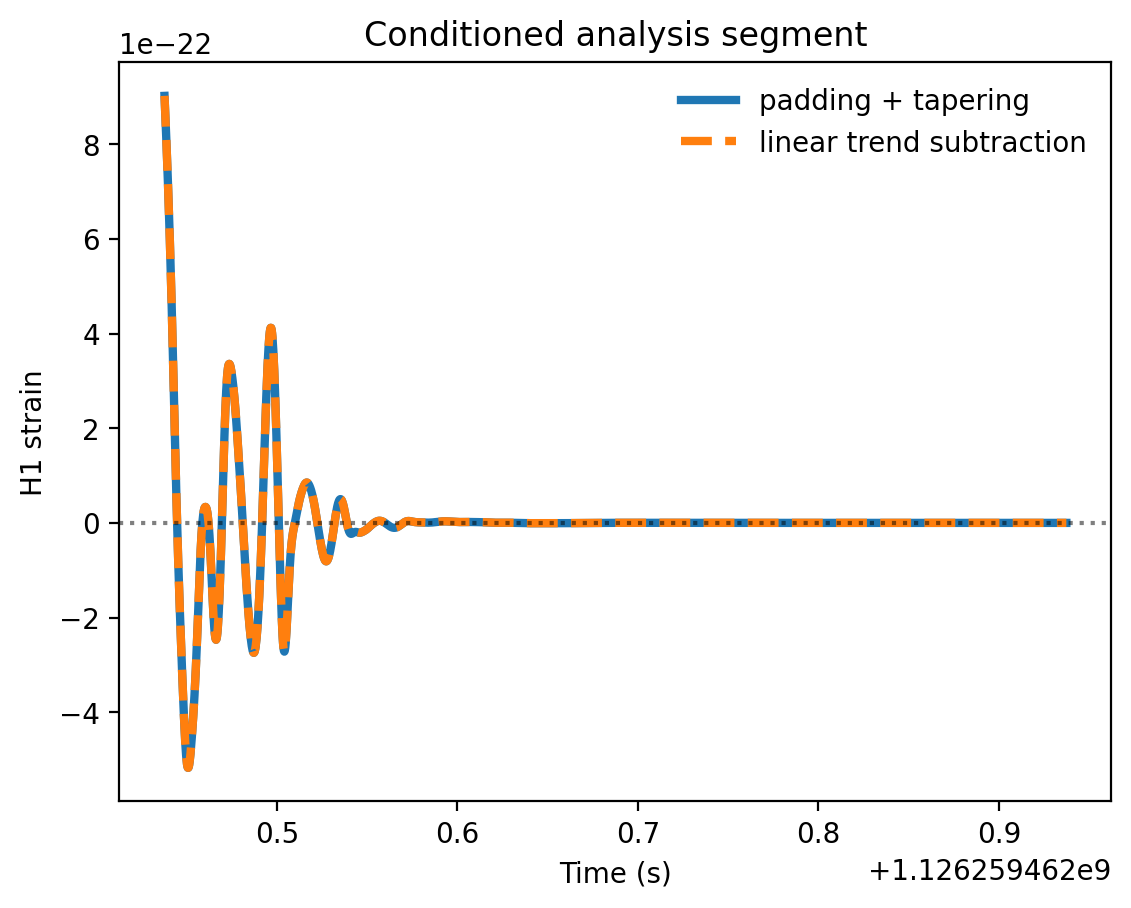

In [36]:
plt.plot(fit_pt.analysis_data['H1'], lw=3, label='padding + tapering')
plt.plot(fit_ls.analysis_data['H1'], ls='--', lw=3, label='linear trend subtraction')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned analysis segment')

plt.legend(frameon=False)

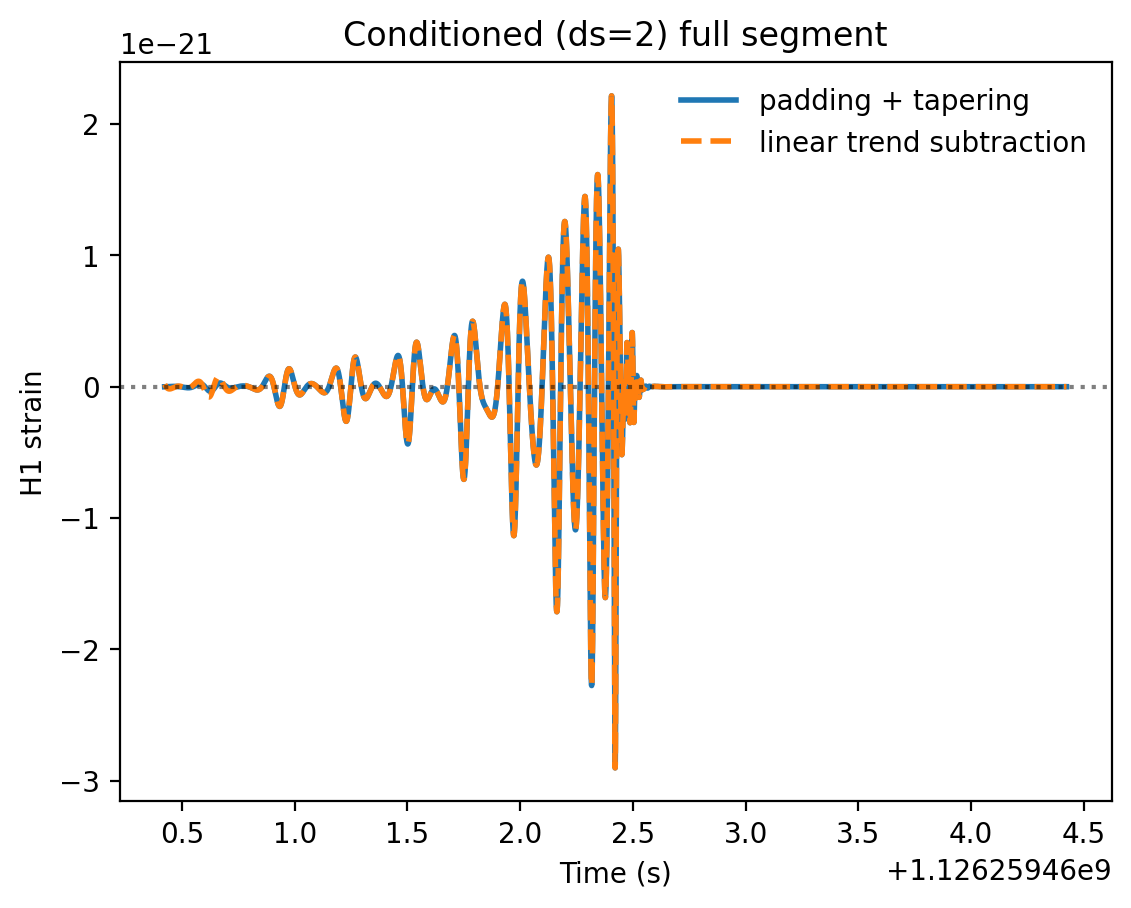

In [37]:
plt.plot(fit_pt.data['H1'], lw=2, label='padding + tapering')
plt.plot(fit_ls.data['H1'], ls='--', lw=2, label='linear trend subtraction')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned (ds=2) full segment')

plt.legend(frameon=False)

In [67]:
TM = rd.qnms.T_MSUN * 321.23764612
9*TM

0.014240278062050842

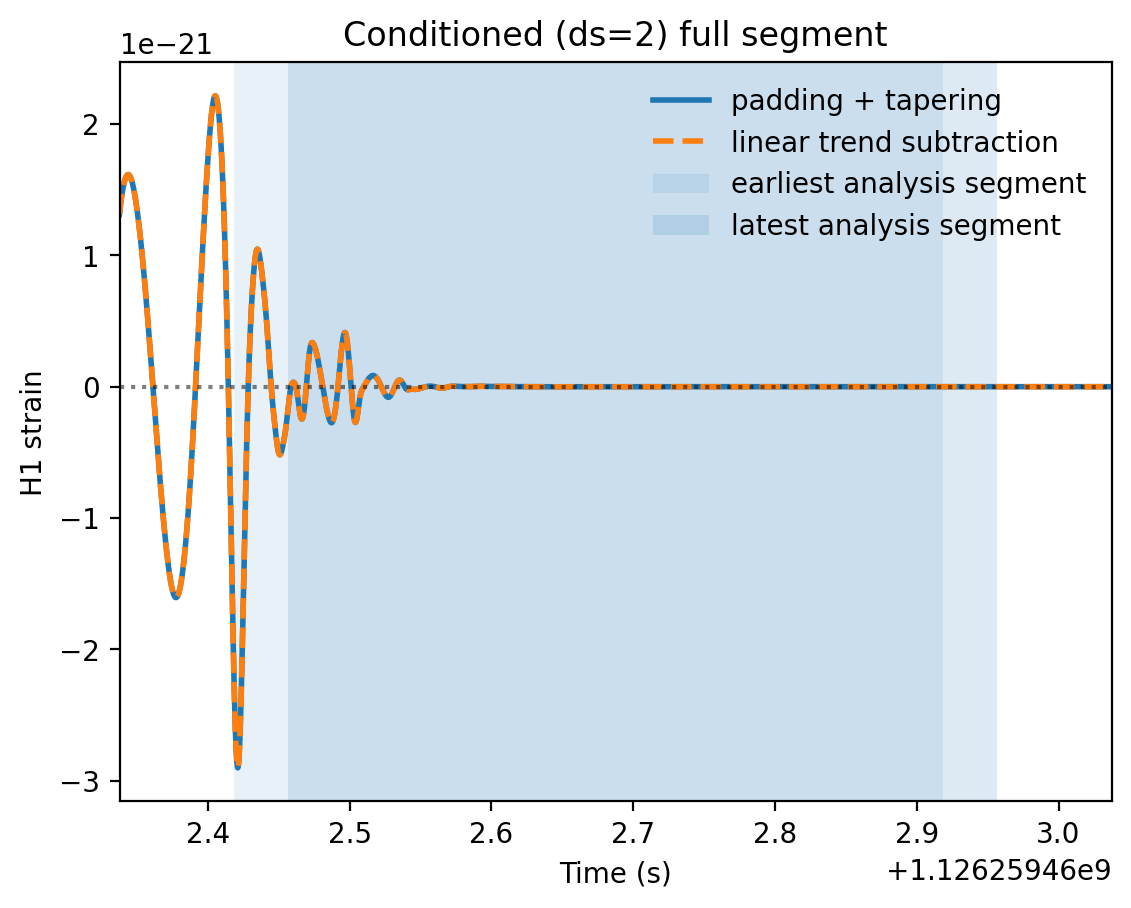

In [78]:
plt.plot(fit_pt.data['H1'], lw=2, label='padding + tapering')
plt.plot(fit_ls.data['H1'], ls='--', lw=2, label='linear trend subtraction')
plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.axvspan(temp_fit.analysis_times['H1'][0] - 12*TM, temp_fit.analysis_times['H1'][-1] - 12*TM, alpha=0.1, lw=0, label='earliest analysis segment')
plt.axvspan(temp_fit.analysis_times['H1'][0] + 12*TM, temp_fit.analysis_times['H1'][-1] + 12*TM, alpha=0.15, lw=0, label='latest analysis segment')

plt.xlim(temp_fit.analysis_times['H1'][0] - 0.1, temp_fit.analysis_times['H1'][-1] + 0.1)

plt.xlabel('Time (s)')
plt.ylabel('H1 strain')
plt.title('Conditioned (ds=2) full segment')

plt.legend(frameon=False)

In [49]:
wd_pt = fit_pt.whiten(fit_pt.data)
wd_ls = fit_ls.whiten(fit_ls.data)

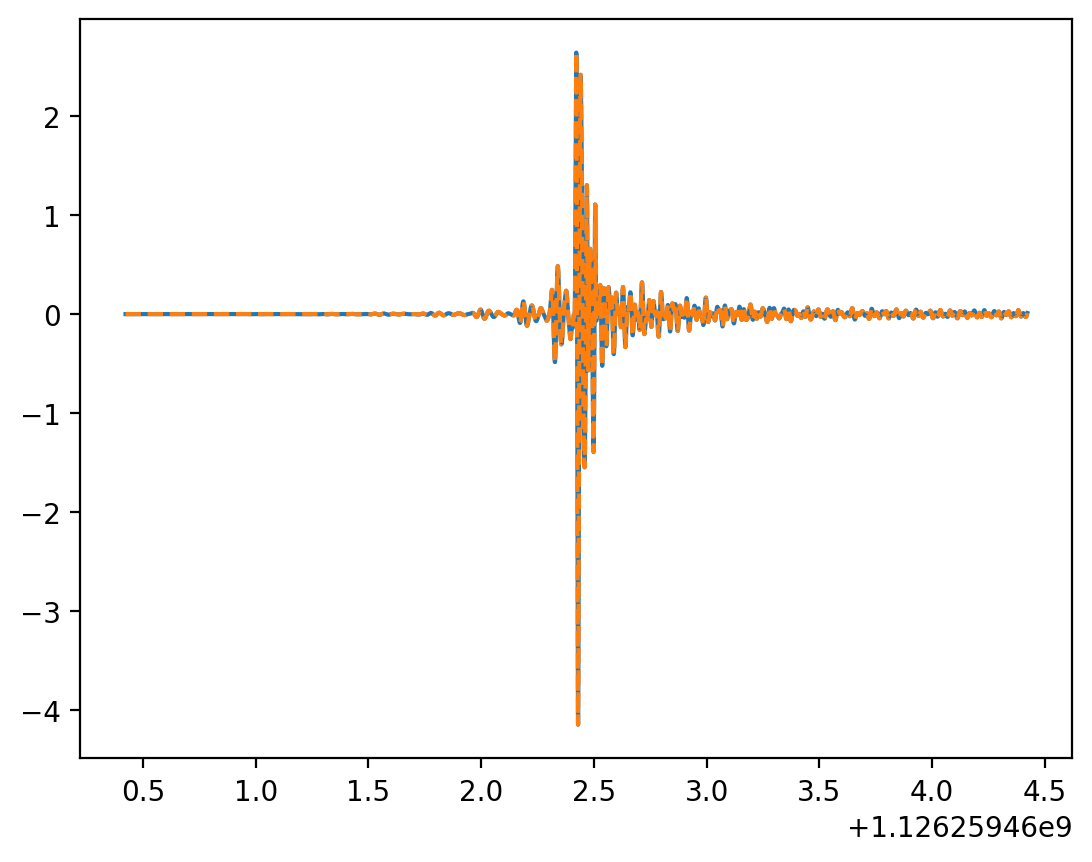

In [50]:
for i, w in wd_pt.items():
    plt.plot(w, label=i)

for i, w in wd_ls.items():
    plt.plot(w, color='C1', ls='--', label=i)

In [54]:
wd_ls['H1'].values

array([1.16870894e-04, 3.47528394e-04, 9.72752835e-05, ...,
       7.05273274e-03, 8.99843973e-03, 1.08910553e-02], shape=(16384,))

(-0.0001, 0.0001)

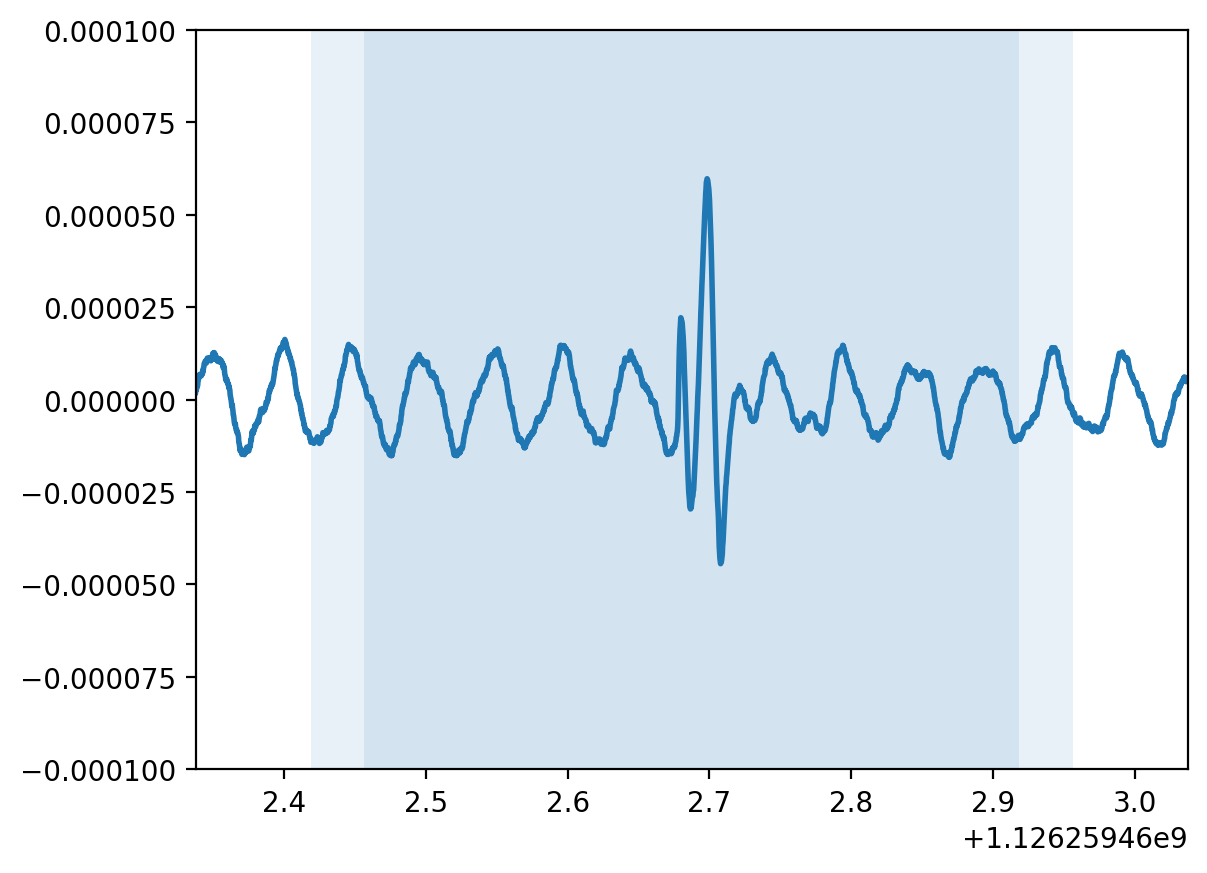

In [70]:
plt.plot(wd_ls['H1'].index.values, (wd_pt['H1'].values - wd_ls['H1'].values), lw=2, label='residual')
plt.axvspan(temp_fit.analysis_times['H1'][0] - 12*TM, temp_fit.analysis_times['H1'][-1] - 12*TM, alpha=0.1, lw=0, label='analysis segment')
plt.axvspan(temp_fit.analysis_times['H1'][0] + 12*TM, temp_fit.analysis_times['H1'][-1] + 12*TM, alpha=0.1, lw=0, label='analysis segment')

plt.xlim(temp_fit.analysis_times['H1'][0] - 0.1, temp_fit.analysis_times['H1'][-1] + 0.1)
plt.ylim(-1e-4, 1e-4)

In [45]:
wa = fit_pt.whiten(fit_pt.analysis_data)

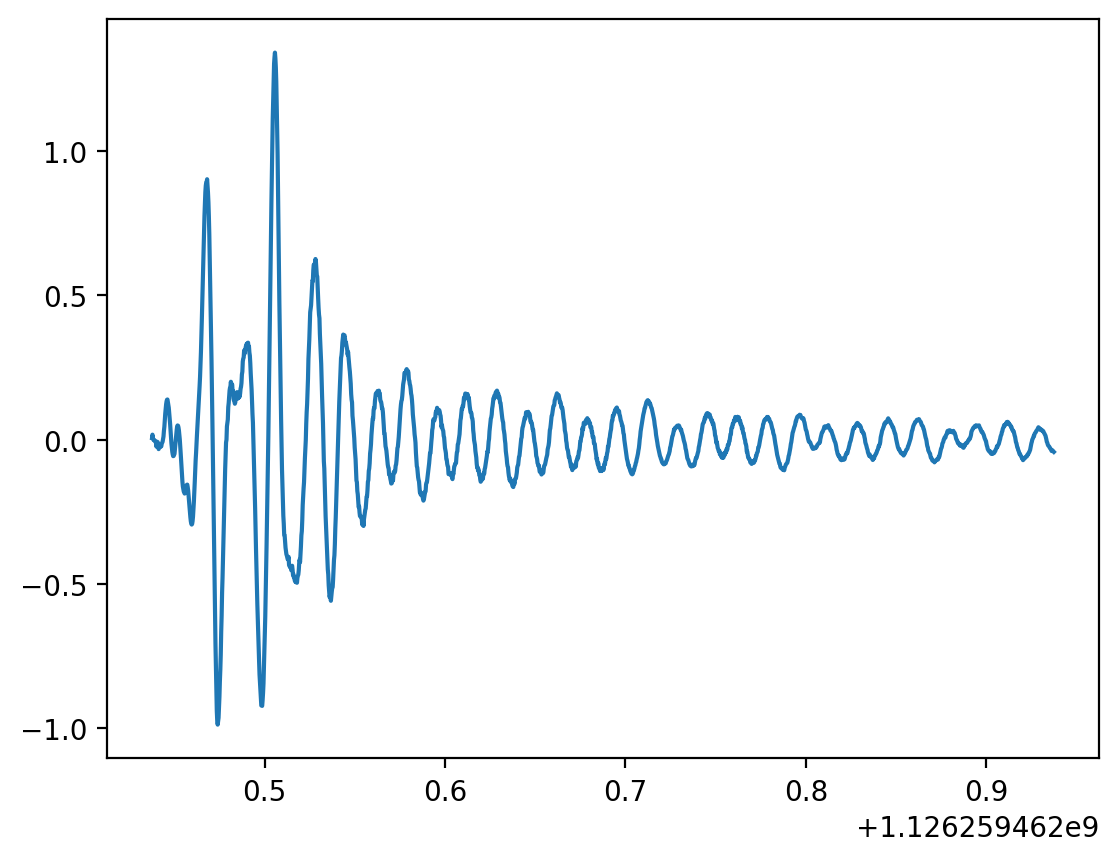

In [46]:
for i, w in wa.items():
    plt.plot(w, label=i)

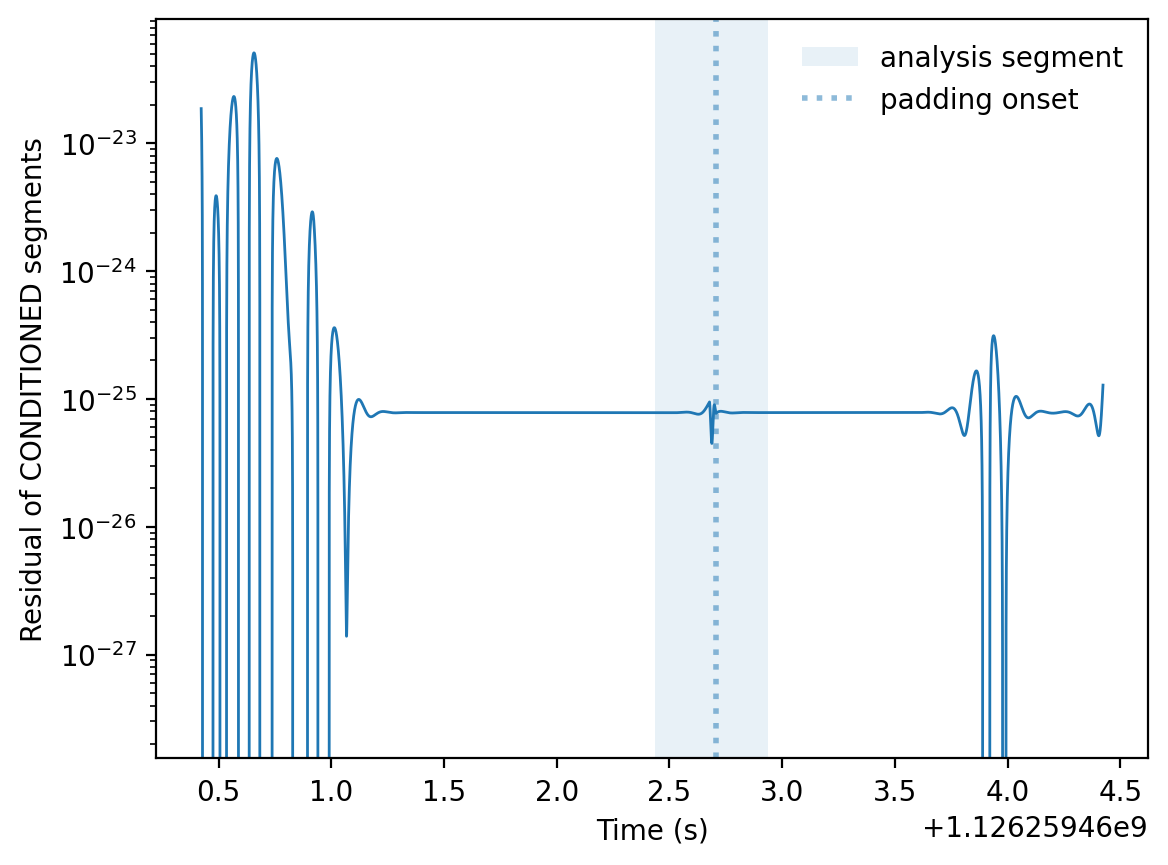

In [226]:
plt.plot(fit_ls.data['H1'] - fit_pt.data['H1'], lw=1)
# plt.axhline(0, color='k', ls=':', alpha=0.5)

plt.axvspan(fit_pt.analysis_times['H1'][0], fit_pt.analysis_times['H1'][-1], alpha=0.1, lw=0, label='analysis segment')
plt.axvline(padding_time, lw=2, alpha=0.5, ls=':', label='padding onset')

plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Residual of CONDITIONED segments')
# plt.title('Conditioned line-subtracted analysis segment')

plt.legend(frameon=False)

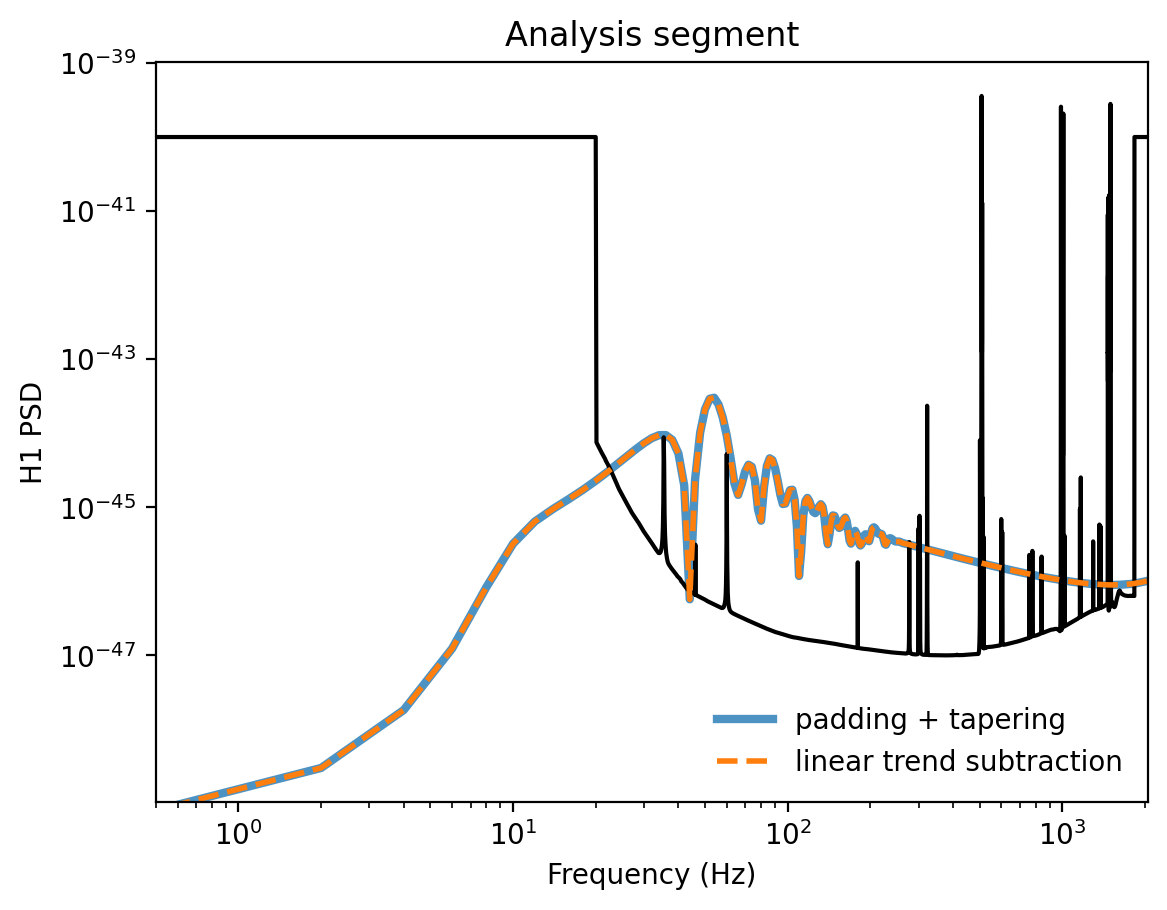

In [208]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')

dt = fit_pt.delta_t
h_freq = np.fft.rfft(fit_pt.analysis_data['H1'].values)*dt
fs = np.fft.rfftfreq(len(fit_pt.analysis_data['H1'].index.values), d=dt)
ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=3, ls='-', alpha=0.8, label='padding + tapering', zorder=-10)

h_freq_c = np.fft.rfft(fit_ls.analysis_data['H1'].values)*dt
fs_c = np.fft.rfftfreq(len(fit_ls.analysis_data['H1'].index.values), d=dt)
ax.loglog(fs_c, 4*fs_c*np.abs(h_freq_c)**2, lw=2, ls='--', label='linear trend subtraction')

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("H1 PSD")
ax.set_title('Analysis segment')
ax.set_xlim(0.5, 2048)
ax.legend(frameon=False)

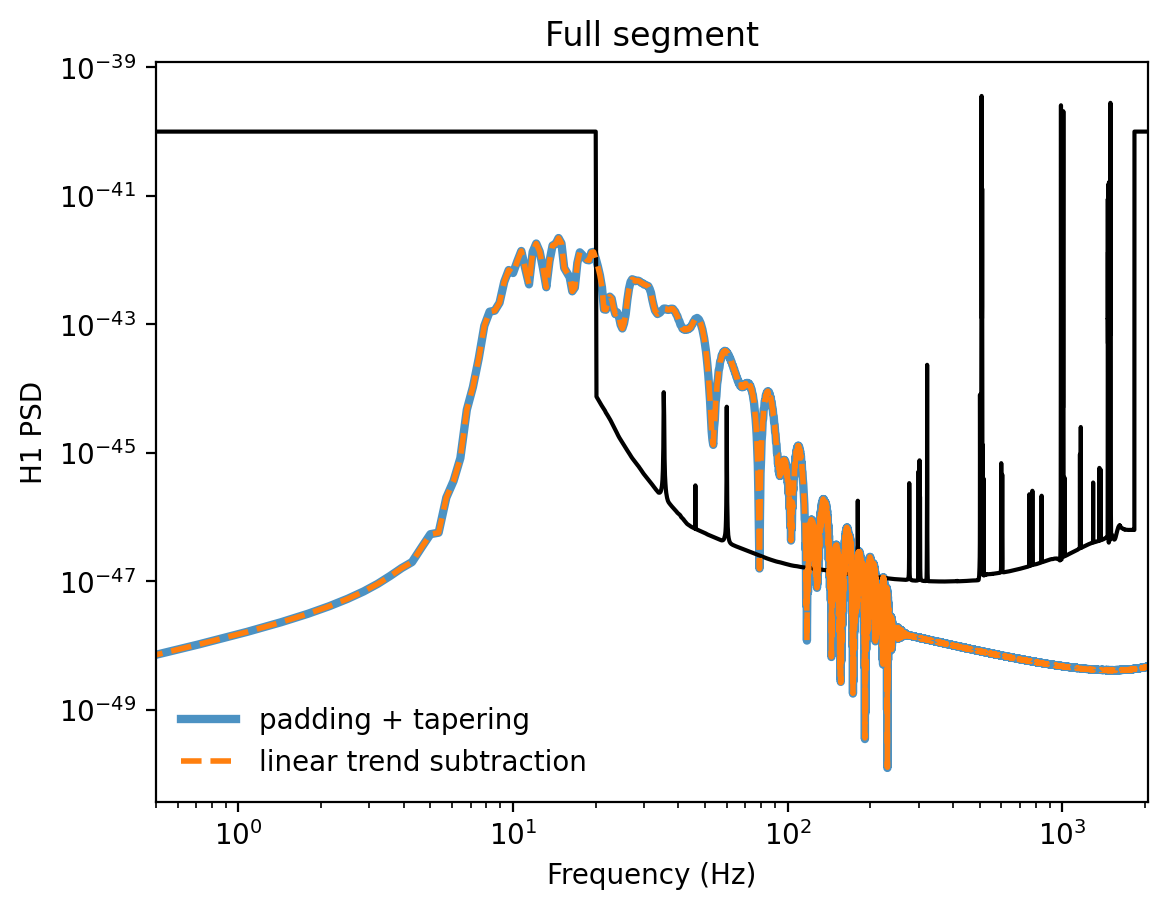

In [209]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')

dt = fit_pt.delta_t
h_freq = np.fft.rfft(fit_pt.data['H1'].values)*dt
fs = np.fft.rfftfreq(len(fit_pt.data['H1'].index.values), d=dt)
ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=3, ls='-', alpha=0.8, label='padding + tapering', zorder=-10)

h_freq_c = np.fft.rfft(fit_ls.data['H1'].values)*dt
fs_c = np.fft.rfftfreq(len(fit_ls.data['H1'].index.values), d=dt)
ax.loglog(fs_c, 4*fs_c*np.abs(h_freq_c)**2, lw=2, ls='--', label='linear trend subtraction')

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("H1 PSD")
ax.set_title('Full segment')
ax.set_xlim(0.5, 2048)
ax.legend(frameon=False)

In [218]:
disc = np.abs(fit_ls.data['H1'].values[0] - fit_ls.data['H1'].values[-1])
np.log10(disc / max(np.abs(fit_ls.data['H1'].values)))

np.float64(-2.394478561778181)